## 1. Foundation & Coverage

We confirm the processed daily dataset loads intact, then map how much history each
city holds. Next-day forecasting needs continuous daily records, so a city's
usefulness depends on two things: how many days it covers, and how complete (gap-free)
that span is. Cities that are too short or too patchy will be filtered out before modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import grid

from src import config

daily = pd.read_parquet(config.DAILY_AQI_PATH)

print("Shape:", daily.shape)
print("Columns:", daily.columns.tolist())
print("Date range:", daily["date"].min(), "->", daily["date"].max())
daily.head()

Shape: (595882, 25)
Columns: ['city', 'state', 'station', 'date', 'pm25', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'o3', 'benzene', 'toluene', 'xylene', 'pm25_n', 'pm10_n', 'so2_n', 'no2_n', 'nh3_n', 'co_n', 'o3_n', 'aqi', 'aqi_bucket']
Date range: 2010-01-01 00:00:00 -> 2023-03-31 00:00:00


,city,state,station,date,pm25,pm10,no,no2,nox,nh3,...,xylene,pm25_n,pm10_n,so2_n,no2_n,nh3_n,co_n,o3_n,aqi,aqi_bucket
0,Agartala,Tripura,TR001,2020-11-08,53.016667,68.795000,1.323333,6.743333,8.565000,4.320000,...,NaN,6,6,6,6,6,6,6,88.200575,Satisfactory
1,Agartala,Tripura,TR001,2020-11-09,42.771304,55.189130,1.668750,6.787083,9.105000,4.706667,...,NaN,23,23,24,24,24,24,24,70.889445,Satisfactory
2,Agartala,Tripura,TR001,2020-11-10,41.183750,54.986250,4.335000,8.927917,15.153333,7.411667,...,NaN,24,24,24,24,24,24,24,68.207026,Satisfactory
3,Agartala,Tripura,TR001,2020-11-11,49.401667,64.949091,1.315833,7.173333,8.950417,4.712083,...,NaN,24,22,24,24,24,24,24,82.092471,Satisfactory
4,Agartala,Tripura,TR001,2020-11-12,45.761250,62.839167,1.043333,7.678333,9.040417,4.743333,...,NaN,24,24,24,24,24,24,24,75.941422,Satisfactory


In [2]:
coverage = (
    daily.groupby("city")
    .agg(
        n_rows=("date", "size"),
        n_unique_days=("date", "nunique"),
        n_stations=("station", "nunique"),
        first_day=("date", "min"),
        last_day=("date", "max"),
    )
    .sort_values("n_unique_days", ascending=False)
)

coverage["span_days"] = (coverage["last_day"] - coverage["first_day"]).dt.days + 1
coverage["completeness"] = (coverage["n_unique_days"] / coverage["span_days"]).round(2)

print("Total cities:", len(coverage))
print("\nTop 10 best-covered cities:")
print(coverage.head(10))
print("\nBottom 10 thinnest cities:")
print(coverage.tail(10))

Total cities: 241

Top 10 best-covered cities:
             n_rows  n_unique_days  n_stations  first_day   last_day  \
city                                                                   
Bengaluru     28732           4838          12 2010-01-01 2023-03-31   
Delhi        116520           4838          40 2010-01-01 2023-03-31   
Chennai       19675           4838           9 2010-01-01 2023-03-31   
Mumbai        26622           4838          21 2010-01-01 2023-03-31   
Lucknow       18765           4838           7 2010-01-01 2023-03-31   
Pune          10794           4838           8 2010-01-01 2023-03-31   
Navi Mumbai    7954           4838           4 2010-01-01 2023-03-31   
Faridabad      7953           4583           4 2010-09-13 2023-03-31   
Agra           7726           4565           6 2010-10-01 2023-03-31   
Varanasi       6496           4565           4 2010-10-01 2023-03-31   

             span_days  completeness  
city                                  
Bengaluru 

### 1b. How much history per city?

The min/max cities show extremes, but the filter threshold depends on the full
distribution. We plot how many cities have how much history, and count how many
clear common thresholds, to choose a defensible minimum-history cutoff in cleaning.

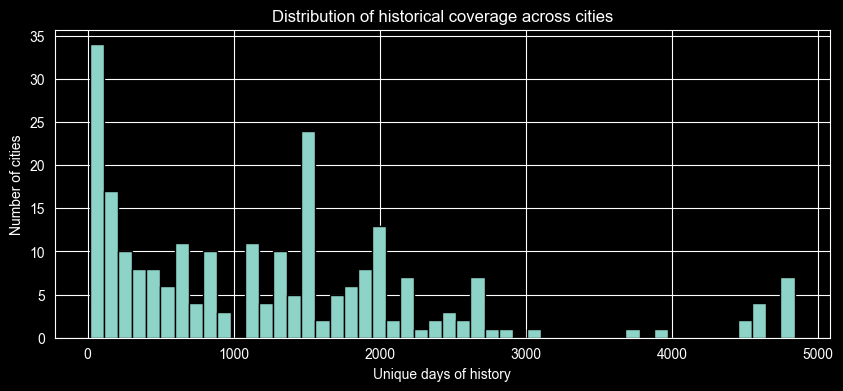

>=   100 days (0.3 yrs): 209 cities survive
>=   365 days (1.0 yrs): 174 cities survive
>=   730 days (2.0 yrs): 147 cities survive
>=  1825 days (5.0 yrs):  63 cities survive
>=  3650 days (10.0 yrs):  15 cities survive


In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(coverage["n_unique_days"], bins=50, edgecolor="black")
ax.set_xlabel("Unique days of history")
ax.set_ylabel("Number of cities")
ax.set_title("Distribution of historical coverage across cities")
plt.show()

for threshold in [100, 365, 730, 1825, 3650]:
    n_cities = (coverage["n_unique_days"] >= threshold).sum()
    print(f">= {threshold:>5} days ({threshold/365:.1f} yrs): {n_cities:>3} cities survive")

## 2. Missingness Audit

Real CPCB data has gaps. Before choosing features, we measure how complete each
pollutant column is across all rows. Columns that are mostly empty cannot be
filled honestly and will be dropped; columns with only small gaps can be
time-filled later. This audit decides which pollutants survive into modeling.

In [4]:
missing = (
    daily.isna().mean()        # fraction missing per column (0.0 -> 1.0)
    .mul(100)                  # turn into a percentage
    .round(1)
    .sort_values(ascending=False)
)

print("Missing % per column (worst first):")
print(missing)

Missing % per column (worst first):
xylene        77.0
toluene       47.4
nh3           37.8
benzene       35.3
pm10          28.9
o3            23.1
pm25          22.0
co            21.2
nox           20.8
so2           19.9
no            19.0
aqi_bucket    19.0
aqi           19.0
no2           16.3
state          0.0
date           0.0
city           0.0
station        0.0
pm25_n         0.0
pm10_n         0.0
so2_n          0.0
nh3_n          0.0
no2_n          0.0
o3_n           0.0
co_n           0.0
dtype: float64


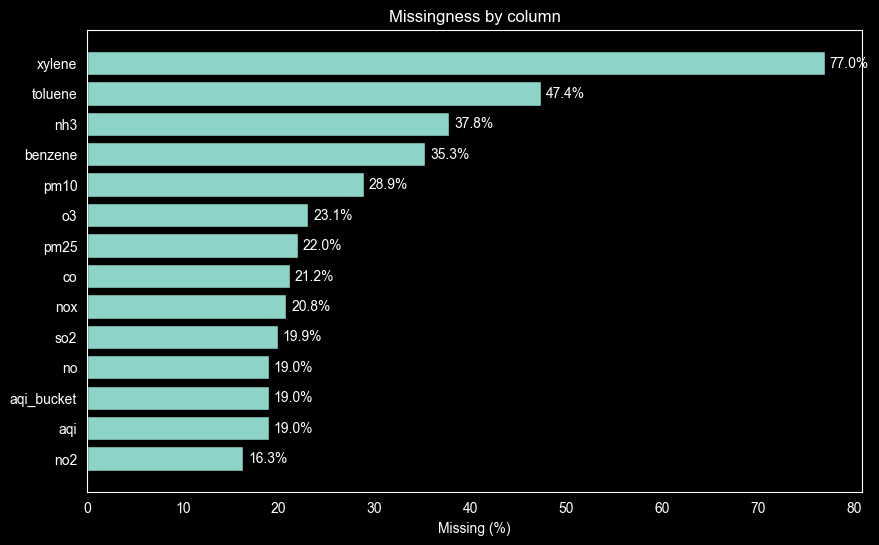

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
missing_nonzero = missing[missing > 0]
ax.barh(missing_nonzero.index, missing_nonzero.values, edgecolor="black",)
ax.grid(False)
ax.invert_yaxis()                       # worst at the top
ax.set_xlabel("Missing (%)")
ax.set_title("Missingness by column")
for i, v in enumerate(missing_nonzero.values):
    ax.text(v + 0.5, i, f"{v}%", va="center")
plt.show()

## 3. The Target Up Close

AirCast predicts two views of the same target: the AQI value (regression) and the
AQI category (classification). Here we examine both. For the value, we look at its
distribution, center, and spread to understand the regression problem's difficulty.
For the category, we measure class balance, since heavy imbalance dictates how the
classifier must be evaluated (weighted F1 and confusion matrix, not raw accuracy).

AQI value summary:
count    482413.0
mean        149.3
std         107.2
min           1.4
25%          71.2
50%         111.7
75%         195.2
max         500.0
Name: aqi, dtype: float64

Skew: 1.24


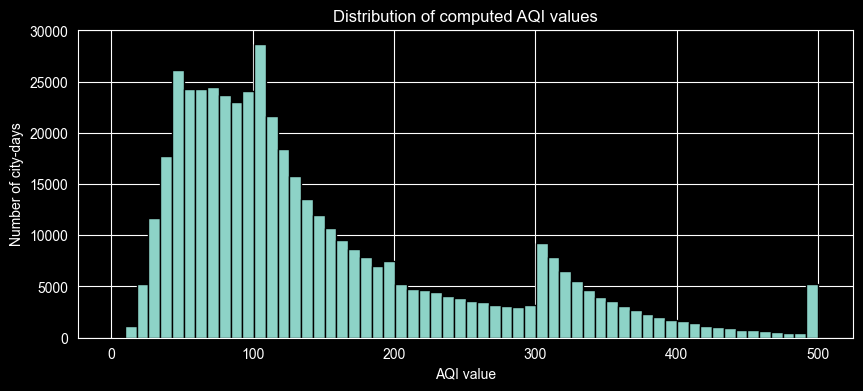

In [6]:
aqi_valid = daily["aqi"].dropna()      # ignore the None rows for this view

print("AQI value summary:")
print(aqi_valid.describe().round(1))
print("\nSkew:", round(aqi_valid.skew(), 2))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(aqi_valid, bins=60, edgecolor="black")
ax.set_xlabel("AQI value")
ax.set_ylabel("Number of city-days")
ax.set_title("Distribution of computed AQI values")
plt.show()

Category counts:
aqi_bucket
Good             58350
Satisfactory    143734
Moderate        164592
Poor             46692
Very Poor        53818
Severe           15227
Name: count, dtype: int64

Category share (%):
aqi_bucket
Good            12.1
Satisfactory    29.8
Moderate        34.1
Poor             9.7
Very Poor       11.2
Severe           3.2
Name: count, dtype: float64

Imbalance ratio (largest : smallest): 10.8 : 1


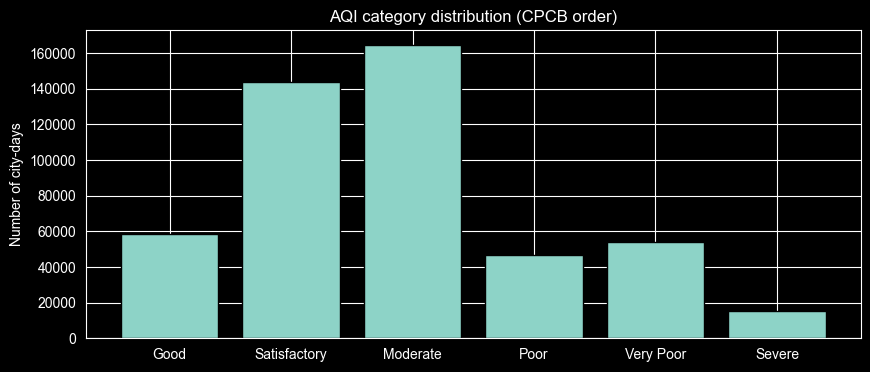

In [7]:
# CPCB category order, worst to best — so the bar reads logically, not alphabetically
bucket_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]

bucket_counts = daily["aqi_bucket"].value_counts().reindex(bucket_order)
bucket_pct = (bucket_counts / bucket_counts.sum() * 100).round(1)

print("Category counts:")
print(bucket_counts)
print("\nCategory share (%):")
print(bucket_pct)
print("\nImbalance ratio (largest : smallest):",
      round(bucket_counts.max() / bucket_counts.min(), 1), ": 1")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(bucket_order, bucket_counts.values, edgecolor="black")
ax.set_ylabel("Number of city-days")
ax.set_title("AQI category distribution (CPCB order)")
plt.show()

## 4. Time & Seasonality

We test whether AQI follows calendar patterns. Air quality in India is expected to
be strongly seasonal — worst in winter, cleaner in the monsoon — and may also drift
across years as monitoring coverage changes. Clear time patterns justify adding
month, season, and day-of-week as model features. Flat patterns would mean those
features add nothing.

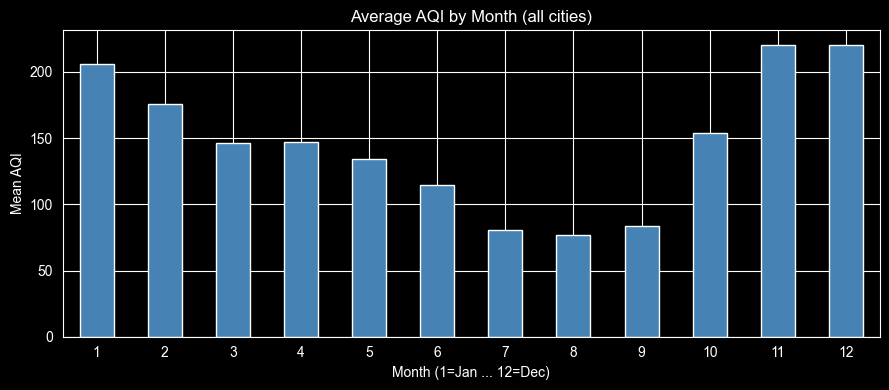

month
1     206.2
2     175.5
3     146.6
4     147.2
5     134.3
6     114.7
7      81.0
8      76.7
9      83.3
10    153.6
11    220.3
12    220.3
Name: aqi, dtype: float64


In [8]:
valid = daily[daily["aqi"].notna()].copy()

valid["year"] = valid["date"].dt.year
valid["month"] = valid["date"].dt.month
valid["dayofweek"] = valid["date"].dt.dayofweek   # Mon=0 ... Sun=6

monthly_aqi = valid.groupby("month")["aqi"].mean()

plt.figure(figsize=(9, 4))
monthly_aqi.plot(kind="bar", color="steelblue")
plt.title("Average AQI by Month (all cities)")
plt.xlabel("Month (1=Jan ... 12=Dec)")
plt.ylabel("Mean AQI")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(monthly_aqi.round(1))

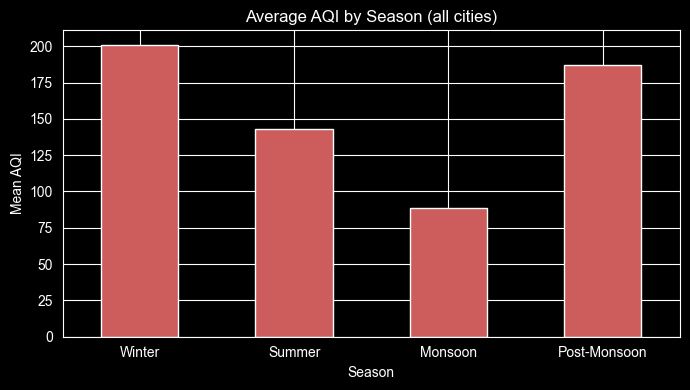

season
Winter          200.9
Summer          143.0
Monsoon          88.5
Post-Monsoon    187.2
Name: aqi, dtype: float64


In [9]:
def month_to_season(month):
    if month in (12, 1, 2):
        return "Winter"
    if month in (3, 4, 5):
        return "Summer"
    if month in (6, 7, 8, 9):
        return "Monsoon"
    return "Post-Monsoon"          # Oct, Nov

valid["season"] = valid["month"].apply(month_to_season)

season_order = ["Winter", "Summer", "Monsoon", "Post-Monsoon"]
season_aqi = valid.groupby("season")["aqi"].mean().reindex(season_order)

plt.figure(figsize=(7, 4))
season_aqi.plot(kind="bar", color="indianred")
plt.title("Average AQI by Season (all cities)")
plt.xlabel("Season")
plt.ylabel("Mean AQI")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(season_aqi.round(1))

In [10]:
yearly = valid.groupby("year")["aqi"].agg(mean_aqi="mean", n_rows="size")
yearly["mean_aqi"] = yearly["mean_aqi"].round(1)
print(yearly)

      mean_aqi  n_rows
year                  
2010     233.9     388
2011     227.4     724
2012     305.5    1534
2013     298.0    1264
2014     233.8    1258
2015     196.3    7502
2016     180.4   12693
2017     171.1   18668
2018     173.0   41572
2019     156.1   63504
2020     133.4   78817
2021     139.1  100258
2022     138.3  119201
2023     160.1   35030


## 5. Persistence Signal

We measure how strongly today's AQI predicts tomorrow's, within each monitoring
series. A naive "tomorrow = today" forecast is the persistence baseline — the bar
every trained model must beat to justify its existence. Strong day-to-day
correlation also confirms that lag features will carry real predictive signal.

In [11]:
# One continuous daily series lives within a single station, so we shift per
# (city, station) — never across a city or station boundary.
pers = valid[["city", "station", "date", "aqi"]].copy()
pers = pers.sort_values(["city", "station", "date"])

grp = pers.groupby(["city", "station"])
pers["aqi_tomorrow"] = grp["aqi"].shift(-1)     # next row's AQI = tomorrow
pers["date_tomorrow"] = grp["date"].shift(-1)

# Keep only pairs where "tomorrow" is literally the next calendar day.
# Without this, a gap (e.g. Jan 3 -> Jan 9) would pair non-adjacent days
# and fake a weaker persistence than reality.
pers["gap"] = (pers["date_tomorrow"] - pers["date"]).dt.days
pairs = pers[pers["gap"] == 1].copy()

print("Valid rows:", len(pers))
print("True consecutive-day pairs:", len(pairs))

Valid rows: 482413
True consecutive-day pairs: 475759


In [12]:
today = pairs["aqi"]
tomorrow = pairs["aqi_tomorrow"]

mae = (tomorrow - today).abs().mean()
rmse = np.sqrt(((tomorrow - today) ** 2).mean())
corr = today.corr(tomorrow)

print("Persistence baseline  (predict tomorrow = today)")
print(f"  MAE  = {mae:.2f}")
print(f"  RMSE = {rmse:.2f}")
print(f"  Correlation(today, tomorrow) = {corr:.3f}")

Persistence baseline  (predict tomorrow = today)
  MAE  = 30.22
  RMSE = 51.00
  Correlation(today, tomorrow) = 0.887


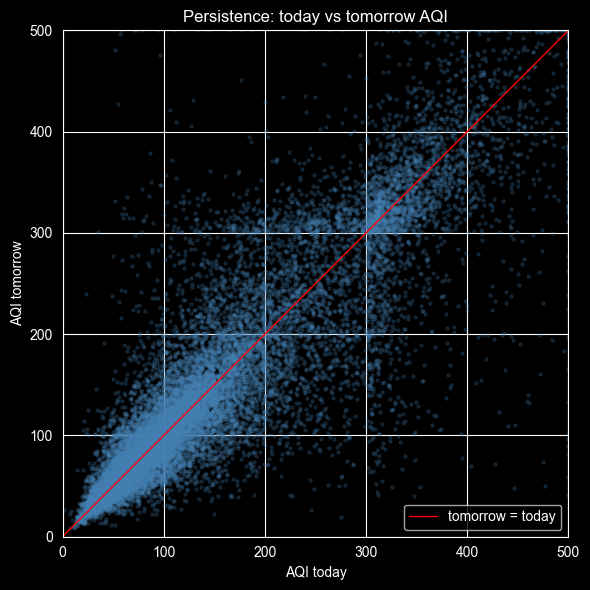

In [13]:
# 400k points would be a black blob — sample for a readable cloud.
sample = pairs.sample(n=20000, random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(sample["aqi"], sample["aqi_tomorrow"], s=5, alpha=0.2, color="steelblue")
plt.plot([0, 500], [0, 500], color="red", linewidth=1, label="tomorrow = today")
plt.xlim(0, 500)
plt.ylim(0, 500)
plt.xlabel("AQI today")
plt.ylabel("AQI tomorrow")
plt.title("Persistence: today vs tomorrow AQI")
plt.legend()
plt.tight_layout()
plt.show()

## 6. City Landscape

We compare AQI across cities to test whether location carries predictive signal.
If cities differ sharply in their typical air quality, the model must know which
city each row belongs to — justifying city as a feature. We also confirm how many
stations sit within each city, which decides whether we model per-station or
collapse stations into one city-level series.

In [16]:
# Bucket 1 decided: only cities with >= 730 unique days are model-worthy.
# We apply that filter HERE FOR ANALYSIS ONLY (no data is modified) so the
# city picture reflects the cities we will actually model.
MIN_CITY_DAYS = 730

days_per_city = valid.groupby("city")["date"].nunique()
survivor_cities = days_per_city[days_per_city >= MIN_CITY_DAYS].index

city_view = valid[valid["city"].isin(survivor_cities)].copy()
print("Survivor cities:", len(survivor_cities))

city_aqi = (
    city_view.groupby("city")["aqi"]
    .agg(mean_aqi="mean", median_aqi="median", n_days="size")
    .sort_values("mean_aqi", ascending=False)
)
city_aqi["mean_aqi"] = city_aqi["mean_aqi"].round(1)
city_aqi["median_aqi"] = city_aqi["median_aqi"].round(1)

print("\nTop 10 dirtiest cities:")
print(city_aqi.head(10))
print("\nTop 10 cleanest cities:")
print(city_aqi.tail(10))

Survivor cities: 142

Top 10 dirtiest cities:
               mean_aqi  median_aqi  n_days
city                                       
Bhiwadi           239.1       240.3    1943
Ghaziabad         233.7       209.6    6377
Delhi             229.0       205.2   81299
Noida             220.6       188.5    6762
Greater Noida     217.4       187.7    3080
Faridabad         215.0       186.3    5705
Baghpat           213.1       190.1    1512
Muzaffarpur       206.0       172.4    3942
Bulandshahr       205.4       185.1    1750
Gurugram          205.2       181.3    6281

Top 10 cleanest cities:
                mean_aqi  median_aqi  n_days
city                                        
Bagalkot            58.7        49.4    1143
Vijayapura          58.3        50.7    1062
Mysuru              57.8        54.8    1287
Maihar              57.3        49.9    1202
Thoothukudi         56.4        51.8     833
Chikkamagaluru      51.4        45.8    1140
Chamarajanagar      48.3        42.5     

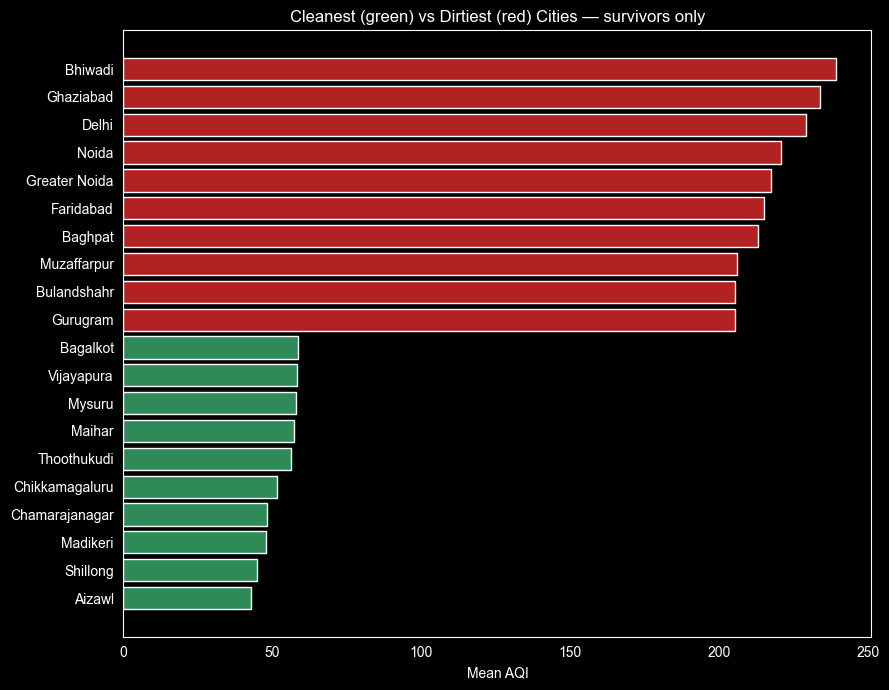

In [18]:
top10 = city_aqi.head(10).sort_values("mean_aqi")
bottom10 = city_aqi.tail(10).sort_values("mean_aqi")
extremes = pd.concat([bottom10, top10])

plt.figure(figsize=(9, 7))
colors = ["seagreen"] * len(bottom10) + ["firebrick"] * len(top10)
plt.barh(extremes.index, extremes["mean_aqi"], color=colors)
plt.grid(False)
plt.xlabel("Mean AQI")
plt.title("Cleanest (green) vs Dirtiest (red) Cities — survivors only")
plt.tight_layout()
plt.show()

In [19]:
stations_per_city = (
    city_view.groupby("city")["station"]
    .nunique()
    .sort_values(ascending=False)
)

print("Cities with the most stations:")
print(stations_per_city.head(10))
print("\nHow many survivor cities have >1 station?")
multi = (stations_per_city > 1).sum()
print(f"  {multi} of {len(stations_per_city)} cities are multi-station")

Cities with the most stations:
city
Delhi        39
Mumbai       21
Hyderabad    14
Bengaluru    12
Ahmedabad     9
Chennai       9
Pune          8
Kolkata       7
Moradabad     7
Lucknow       7
Name: station, dtype: int64

How many survivor cities have >1 station?
  45 of 142 cities are multi-station


## 7. Pollutant Relationships

We examine how pollutants relate to AQI and to each other. Because AQI is the worst
of its pollutant sub-indices, the pollutant most correlated with AQI is the one that
typically decides it — telling us which pollutant carries the most signal worth
lagging. We also check for redundant pollutant pairs that measure nearly the same
thing, which can destabilize linear models.

In [20]:
# Pollutant columns live in config as the single source of truth.
# If your constant is named differently, swap config.POLLUTANT_COLS below.
pollutant_cols = config.POLLUTANT_COLS

corr_cols = pollutant_cols + ["aqi"]
corr_matrix = valid[corr_cols].corr()

aqi_corr = corr_matrix["aqi"].drop("aqi").sort_values(ascending=False)
print("Correlation of each pollutant with AQI (strongest driver first):")
print(aqi_corr.round(3))

Correlation of each pollutant with AQI (strongest driver first):
pm10       0.931
pm25       0.900
no2        0.479
co         0.472
nox        0.439
no         0.382
nh3        0.369
o3         0.271
toluene    0.230
so2        0.167
benzene    0.155
xylene     0.063
Name: aqi, dtype: float64


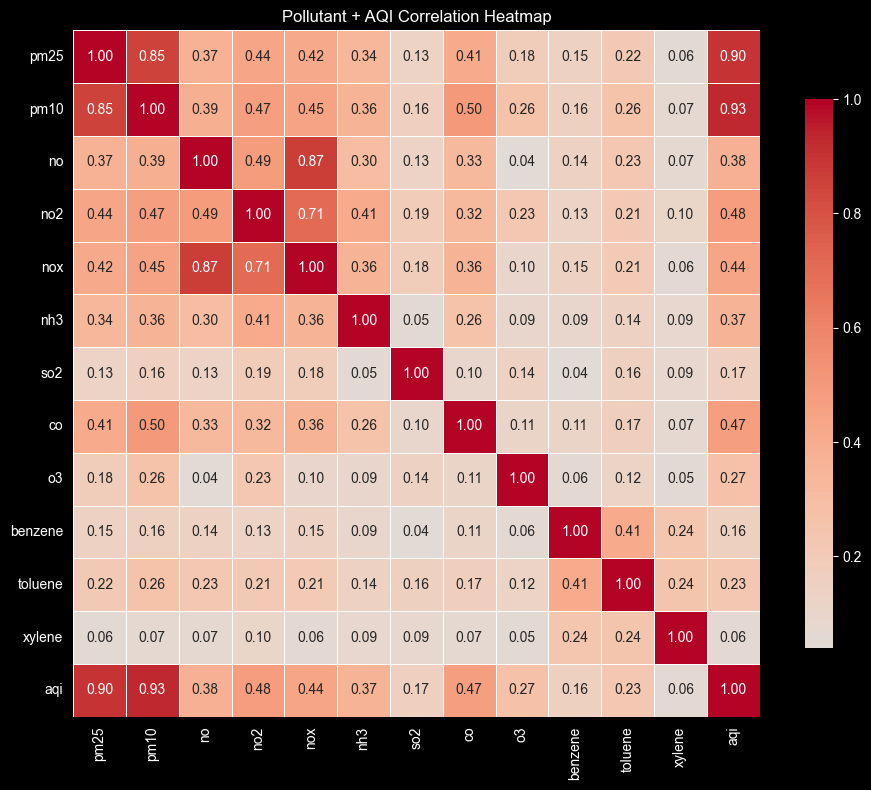

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Pollutant + AQI Correlation Heatmap")
plt.tight_layout()
plt.show()